# Neuropainting → AnnData

Brain cell types profiled with a Neuropainting variant of the assay ([`cpg0038`](https://broadinstitute.github.io/cellpainting-gallery/)). Batches split astrocytes from neurons and 20x from 63x imaging, so they are not comparable feature-wise.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0038-tegtmeyer-neuropainting/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0038-tegtmeyer-neuropainting/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

3 batches, using NCP_ASTROCYTES_1


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 188 × 565
    obs: 'plate_map_name', 'METADATA_SAMPLE_ID', 'METADATA_DENSITY', 'METADATA_CONDITION', 'METADATA_SOURCE', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_Cytoplasm', 'Count_Nuclei', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "plate_map_name", "METADATA_CONDITION", "METADATA_SOURCE"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_10_DNA,image,granularity,dna,NaN,1
Image_Granularity_11_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_11_DNA,image,granularity,dna,NaN,1
Image_Granularity_11_ER,image,granularity,er,NaN,1
...,...,...,...,...,...
Nuclei_Texture_InfoMeas1_Brightfield_5_00,nuclei,texture,brightfield,NaN,1
Nuclei_Texture_InfoMeas1_DNA_5_02,nuclei,texture,dna,NaN,1
Nuclei_Texture_InfoMeas1_RNA_5_00,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["METADATA_CONDITION", "METADATA_SOURCE"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

188 wells x 563 features
non-finite: 0 | max|x|: 29327.0

METADATA_CONDITION:
METADATA_CONDITION
DELETION    96
CONTROL     92

METADATA_SOURCE:
METADATA_SOURCE
HUMAN       172
ISOGENIC     16


In [6]:
adata.write_h5ad(PROFILES.parent / "neuropainting.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "METADATA_CONDITION", "METADATA_SOURCE"]))

,observed,baseline,ratio
covariate,,,
Plate,0.644,0.500,1.287
METADATA_CONDITION,0.671,0.500,1.341
METADATA_SOURCE,0.884,0.844,1.048


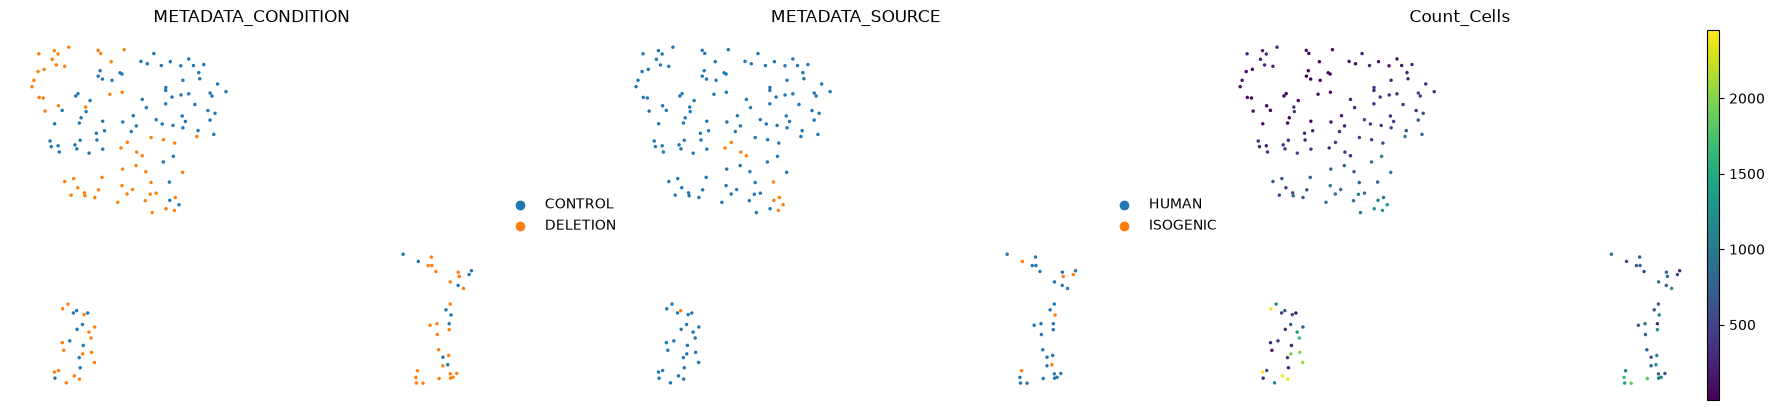

In [9]:
colours = present(["METADATA_CONDITION", "METADATA_SOURCE", "Count_Cells"])[:3] or None
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=25)